
# StackEval Benchmark Recreation - Human Scoring Analysis

## Professional notebook for the final human evaluation results

This notebook analyzes the human scoring phase of the **StackEval Benchmark recreation** project.  
The project recreates a smaller version of StackEval by using **real coding questions**, collecting answers from **four LLMs**, and evaluating those answers with **human scorers** on a **0-3 rubric**. The project goal is to understand which models are most useful on practical developer questions rather than only on academic benchmarks.

### Project context
- **Scorer 1:** Fatih - 4th semester GenAI student
- **Scorer 2:** Ömer Faruk - 8th semester internship student
- **Evaluation design:** 30 questions x 4 models x 2 scorers = 240 scored answers
- **Models compared:** GPT-5.4, Claude Sonnet 4.6, Llama 4 Maverick, GPT-5.4-mini

### Main questions in this notebook
1. Which model performed best and worst overall?
2. How close were the two scorers to each other?
3. Were the scoring differences small or large?
4. What are the most interesting findings for the project report and portfolio?

### Why the combined file matters
For **overall model ranking**, the mixed file is the correct basis because it combines both human perspectives into one evaluation dataset.  
For **scorer comparison**, the individual files still matter because they show whether the two evaluators judged the answers similarly or differently.


In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import cohen_kappa_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# There are three Excel files which include the human scores for the 120 answers:
# - human_scores.xlsx
# - human_scoresv2.xlsx
# - combined_human_scores.xlsx


fatih_path = Path("fatih_scores.xlsx")
omer_path = Path("omerfaruk_scoresv2.xlsx")
combined_path = Path("combined_human_scores.xlsx")

required_files = [fatih_path, omer_path, combined_path]
missing_files = [str(file) for file in required_files if not file.exists()]

if missing_files:
    current_folder = Path.cwd()
    available_files = sorted([p.name for p in current_folder.iterdir() if p.is_file()])
    raise FileNotFoundError(
        "These files were not found in the current notebook folder: "
        + ", ".join(missing_files)
        + f"\n\nCurrent folder: {current_folder}"
        + "\nAvailable files in this folder: "
        + (", ".join(available_files) if available_files else "No files found")
        + "\n\nMove the Excel files into the same folder as the notebook, or edit the paths above."
    )

fatih = pd.read_excel(fatih_path)
omer = pd.read_excel(omer_path)
combined = pd.read_excel(combined_path)

display(Markdown(
    f"Loaded files successfully from the notebook folder:\n\n"
    f"- `{fatih_path.resolve()}`\n"
    f"- `{omer_path.resolve()}`\n"
    f"- `{combined_path.resolve()}`"
))

Loaded files successfully from the notebook folder:

- `C:\Users\koran\Desktop\Semester 4 GenAI\First Project\test\fatih_scores.xlsx`
- `C:\Users\koran\Desktop\Semester 4 GenAI\First Project\test\omerfaruk_scoresv2.xlsx`
- `C:\Users\koran\Desktop\Semester 4 GenAI\First Project\test\combined_human_scores.xlsx`


## 1. Data validation

Before interpreting results, it is important to confirm that the scoring dataset is structurally correct.  
The expected design is:

- **30 questions**
- **4 models per question**
- **2 scorers**
- **Total expected rows = 240**


In [12]:

summary = {
    "Fatih rows": len(fatih),
    "Ömer Faruk rows": len(omer),
    "Combined rows": len(combined),
    "Unique questions in combined": combined["question_number"].nunique(),
    "Unique models in combined": combined["model"].nunique(),
    "Unique scorers in combined": combined["scorer_name"].nunique(),
}
display(pd.DataFrame(summary.items(), columns=["Check", "Value"]))

expected_rows = 30 * 4 * 2
display(Markdown(
    "**Validation result:** "
    + ("The combined file is complete and structurally correct." if len(combined) == expected_rows else "The combined file does not match the expected row count.")
))


,Check,Value
0,Fatih rows,120
1,Ömer Faruk rows,120
2,Combined rows,240
3,Unique questions in combined,30
4,Unique models in combined,4
5,Unique scorers in combined,2


**Validation result:** The combined file is complete and structurally correct.


## 2. Prepare labels and helper tables

The notebook keeps the original files, but standardizes the model labels for cleaner reporting and graphs.


In [13]:

model_name_map = {
    "gpt-5.4": "GPT-5.4",
    "claude-sonnet-4-6": "Claude Sonnet 4.6",
    "meta-llama/llama-4-maverick": "Llama 4 Maverick",
    "gpt-5.4-mini": "GPT-5.4-mini",
}

model_category_map = {
    "gpt-5.4": "Frontier proprietary",
    "claude-sonnet-4-6": "Frontier competitor",
    "meta-llama/llama-4-maverick": "Open-source",
    "gpt-5.4-mini": "Budget / lightweight",
}

for df in (fatih, omer, combined):
    df["model_clean"] = df["model"].map(model_name_map)
    df["category_clean"] = df["model"].map(model_category_map)

key = ["question_number", "model", "model_clean", "category_clean", "answer_label"]
merged = (
    fatih[key + ["score"]]
    .merge(omer[key + ["score"]], on=key, suffixes=("_fatih", "_omer"))
)
merged["diff"] = merged["score_fatih"] - merged["score_omer"]
merged["abs_diff"] = merged["diff"].abs()

display(merged.head())


,question_number,model,model_clean,category_clean,answer_label,score_fatih,score_omer,diff,abs_diff
0,1,gpt-5.4,GPT-5.4,Frontier proprietary,Answer A,2,2,0,0
1,1,claude-sonnet-4-6,Claude Sonnet 4.6,Frontier competitor,Answer B,3,3,0,0
2,1,meta-llama/llama-4-maverick,Llama 4 Maverick,Open-source,Answer C,3,3,0,0
3,1,gpt-5.4-mini,GPT-5.4-mini,Budget / lightweight,Answer D,2,2,0,0
4,2,gpt-5.4,GPT-5.4,Frontier proprietary,Answer A,3,3,0,0



## 3. Overall model ranking

This section answers the most direct benchmark question:

**Which model scored best overall after combining both human scorers?**

In [14]:

overall_model = (
    combined.groupby(["model_clean", "category_clean"])["score"]
    .agg(avg_score="mean", total_score="sum", n="count", std="std")
    .reset_index()
    .sort_values("avg_score", ascending=False)
)
overall_model["pct_of_max"] = overall_model["avg_score"] / 3 * 100
overall_model["three_rate"] = (
    combined.groupby("model_clean")["score"].apply(lambda s: (s == 3).mean()).reindex(overall_model["model_clean"]).values * 100
)
overall_model["score_2_or_more_rate"] = (
    combined.groupby("model_clean")["score"].apply(lambda s: (s >= 2).mean()).reindex(overall_model["model_clean"]).values * 100
)

display(overall_model.round(3))


,model_clean,category_clean,avg_score,total_score,n,std,pct_of_max,three_rate,score_2_or_more_rate
0,Claude Sonnet 4.6,Frontier competitor,2.933,176,60,0.252,97.778,93.333,100.0
1,GPT-5.4,Frontier proprietary,2.833,170,60,0.376,94.444,83.333,100.0
2,GPT-5.4-mini,Budget / lightweight,2.750,165,60,0.437,91.667,75.000,100.0
3,Llama 4 Maverick,Open-source,2.517,151,60,0.596,83.889,56.667,95.0


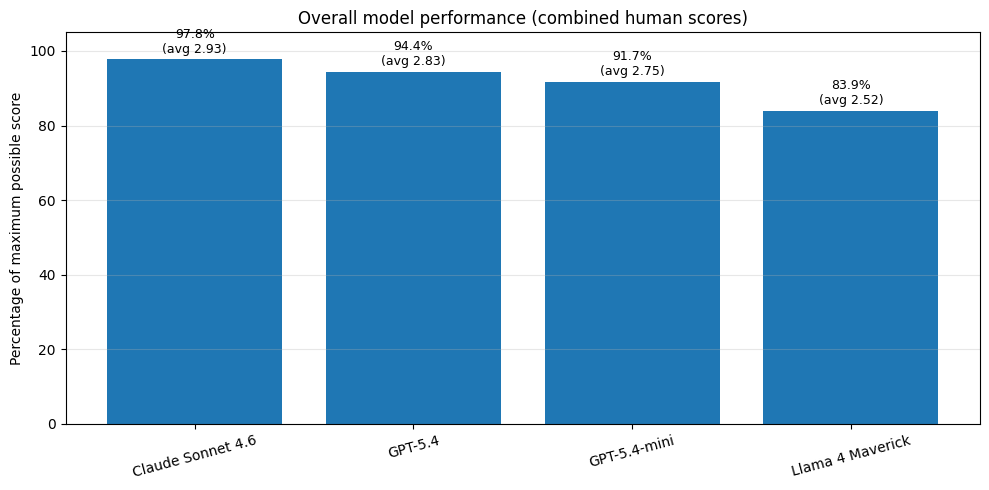

In [15]:

plot_df = overall_model.copy()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(plot_df["model_clean"], plot_df["pct_of_max"])
ax.set_title("Overall model performance (combined human scores)")
ax.set_ylabel("Percentage of maximum possible score")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)

for bar, value, avg in zip(bars, plot_df["pct_of_max"], plot_df["avg_score"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%\n(avg {avg:.2f})",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



## 4. Individual scorer comparison

The combined ranking is important, but your project also becomes more interesting when we separate the two human scorers.

This section shows:
- how **Fatih** scored each model,
- how **Ömer Faruk** scored each model,



In [16]:

by_scorer_model = (
    combined.groupby(["scorer_name", "model_clean"])["score"]
    .mean()
    .unstack()
    .reindex(index=["Fatih", "Ömer Faruk"])
)
by_scorer_pct = by_scorer_model / 3 * 100

display(Markdown("### Average score by scorer and model"))
display(by_scorer_model.round(3))

display(Markdown("### Percentage of maximum score by scorer and model"))
display(by_scorer_pct.round(2))

overall_by_scorer = combined.groupby("scorer_name")["score"].mean().to_frame("avg_score")
overall_by_scorer["pct_of_max"] = overall_by_scorer["avg_score"] / 3 * 100
display(Markdown("### Overall strictness / generosity"))
display(overall_by_scorer.round(3))


### Average score by scorer and model

model_clean,Claude Sonnet 4.6,GPT-5.4,GPT-5.4-mini,Llama 4 Maverick
scorer_name,,,,
Fatih,3.000,2.800,2.6,2.300
Ömer Faruk,2.867,2.867,2.9,2.733


### Percentage of maximum score by scorer and model

model_clean,Claude Sonnet 4.6,GPT-5.4,GPT-5.4-mini,Llama 4 Maverick
scorer_name,,,,
Fatih,100.00,93.33,86.67,76.67
Ömer Faruk,95.56,95.56,96.67,91.11


### Overall strictness / generosity

,avg_score,pct_of_max
scorer_name,,
Fatih,2.675,89.167
Ömer Faruk,2.842,94.722


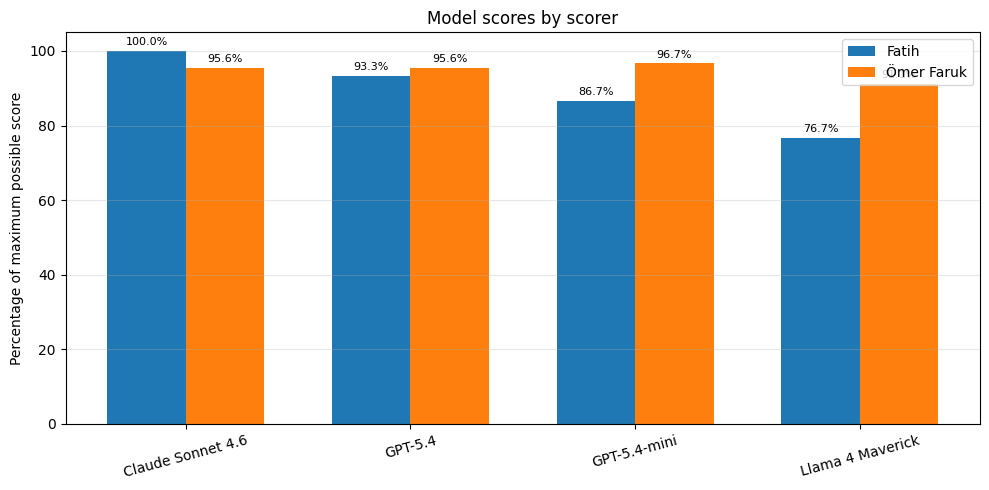

In [17]:

plot_df = by_scorer_pct.T.copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df.index))
width = 0.35

bars1 = ax.bar(x - width/2, plot_df["Fatih"], width, label="Fatih")
bars2 = ax.bar(x + width/2, plot_df["Ömer Faruk"], width, label="Ömer Faruk")

ax.set_title("Model scores by scorer")
ax.set_ylabel("Percentage of maximum possible score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


## 5. Model performance by programming language

Because your benchmark used a **fixed language split**, we can also compare model quality by topic:

- **Questions 1–10** -> Python
- **Questions 11–20** -> C#
- **Questions 21–30** -> Java

This section keeps the analysis simple and useful:
it shows **which model was best overall**, but also **which model looked strongest for each programming language**.

In [23]:
def assign_language(question_number):
    if 1 <= question_number <= 10:
        return "Python"
    elif 11 <= question_number <= 20:
        return "C#"
    elif 21 <= question_number <= 30:
        return "Java"
    return "Other"

for df in (fatih, omer, combined):
    df["language"] = df["question_number"].apply(assign_language)

language_check = combined[["question_number", "language"]].drop_duplicates().sort_values("question_number")
display(Markdown("### Language mapping check"))
display(language_check.head(12))
display(language_check.tail(12))

### Language mapping check

,question_number,language
0,1,Python
8,2,Python
16,3,Python
24,4,Python
32,5,Python
40,6,Python
48,7,Python
56,8,Python
64,9,Python
72,10,Python


,question_number,language
144,19,C#
152,20,C#
160,21,Java
168,22,Java
176,23,Java
184,24,Java
192,25,Java
200,26,Java
208,27,Java
216,28,Java


In [24]:
language_model_scores = (
    combined.groupby(["language", "model_clean"])["score"]
    .mean()
    .unstack()
    .reindex(["Python", "C#", "Java"])
)

language_model_pct = (language_model_scores / 3 * 100).round(1)

display(Markdown("### Average score per model and programming language"))
display(language_model_scores.round(2))

display(Markdown("### Percentage per model and programming language"))
display(language_model_pct)

best_language_models = (
    combined.groupby(["language", "model_clean"])["score"]
    .mean()
    .reset_index()
    .sort_values(["language", "score"], ascending=[True, False])
    .groupby("language")
    .head(1)
    .reset_index(drop=True)
    .rename(columns={"score": "avg_score"})
)

display(Markdown("### Best model inside each language"))
display(best_language_models.round(2))

### Average score per model and programming language

model_clean,Claude Sonnet 4.6,GPT-5.4,GPT-5.4-mini,Llama 4 Maverick
language,,,,
Python,2.9,2.75,2.75,2.75
C#,2.9,2.80,2.70,2.40
Java,3.0,2.95,2.80,2.40


### Percentage per model and programming language

model_clean,Claude Sonnet 4.6,GPT-5.4,GPT-5.4-mini,Llama 4 Maverick
language,,,,
Python,96.7,91.7,91.7,91.7
C#,96.7,93.3,90.0,80.0
Java,100.0,98.3,93.3,80.0


### Best model inside each language

,language,model_clean,avg_score
0,C#,Claude Sonnet 4.6,2.9
1,Java,Claude Sonnet 4.6,3.0
2,Python,Claude Sonnet 4.6,2.9


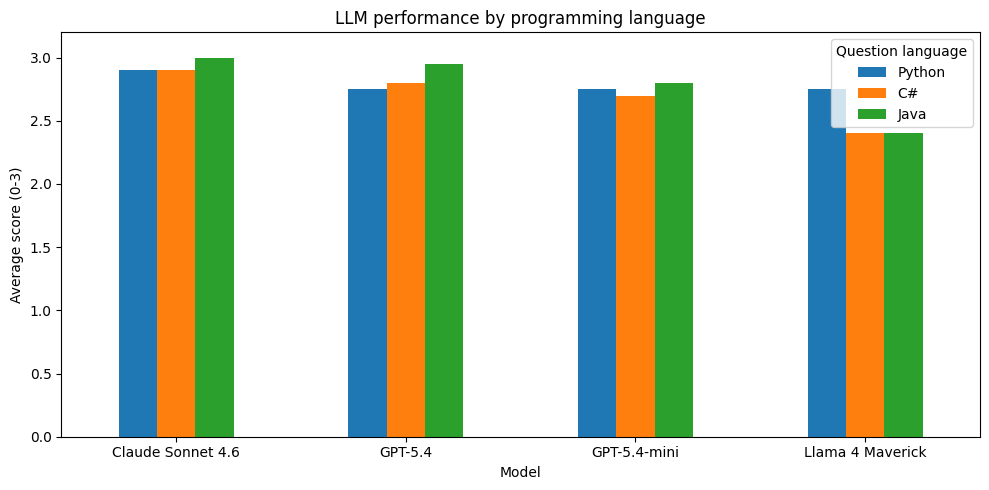

In [25]:
plot_df = language_model_scores.T
ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("LLM performance by programming language")
ax.set_xlabel("Model")
ax.set_ylabel("Average score (0-3)")
ax.set_ylim(0, 3.2)
ax.legend(title="Question language")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Best vs worst language for each model

,model,best_language,best_score,worst_language,worst_score,range_between_best_and_worst
0,Llama 4 Maverick,Python,2.75,C#,2.40,0.35
1,GPT-5.4,Java,2.95,Python,2.75,0.20
2,Claude Sonnet 4.6,Java,3.00,Python,2.90,0.10
3,GPT-5.4-mini,Java,2.80,C#,2.70,0.10


### Quick interpretation

- **Claude Sonnet 4.6** was the strongest model in **all three languages**.
- **Java** was the best-performing language overall for the top models.
- **GPT-5.4** improved from **2.75** on Python to **2.95** on Java.
- **GPT-5.4-mini** stayed competitive and remained close to GPT-5.4 across the language split.
- **Llama 4 Maverick** was clearly stronger on **Python** than on **C#** or **Java**, which is one of the most interesting language-specific patterns in the benchmark.


## 7. Final interpretation

The last cell turns the numbers into direct conclusions.  
These conclusions are based on the actual scoring results in the uploaded files.

In [28]:

best_row = overall_model.iloc[0]
worst_row = overall_model.iloc[-1]

fatih_avg = merged["score_fatih"].mean()
omer_avg = merged["score_omer"].mean()
exact_agreement = (merged["abs_diff"] == 0).mean() * 100
within_1 = (merged["abs_diff"] <= 1).mean() * 100
mean_abs_diff = merged["abs_diff"].mean()

key_findings = f"""
### Executive summary

**1. Best overall model**
- **{best_row['model_clean']}** performed best overall with an average score of **{best_row['avg_score']:.2f} / 3**
- That equals **{best_row['pct_of_max']:.1f}%** of the maximum possible score

**2. Worst overall model**
- **{worst_row['model_clean']}** performed worst overall with an average score of **{worst_row['avg_score']:.2f} / 3**
- That equals **{worst_row['pct_of_max']:.1f}%** of the maximum possible score

**3. Were the two scorers very different?**
- Not really.
- Exact agreement happened on **{exact_agreement:.1f}%** of all answers
- Agreement within 1 point happened on **{within_1:.1f}%** of all answers
- The average disagreement size was only **{mean_abs_diff:.2f} points**

**4. Who was stricter?**
- **Fatih** was stricter overall with an average score of **{fatih_avg:.2f}**
- **Ömer Faruk** was more generous overall with an average score of **{omer_avg:.2f}**

**5. Most interesting pattern**
- The biggest scorer disagreement did **not** come from random chaos.
- The largest model-specific disagreement came from **Llama 4 Maverick**, which had the highest average scorer gap

**6. Strong project insight**
- The ranking is especially interesting because the **budget model (GPT-5.4-mini)** stayed surprisingly strong.
- It did **not** beat the top model overall, but it remained much closer to the frontier models than the open-source model did.
- That makes the cost-versus-quality comparison meaningful for your project.


### Short conclusion

Your project already produces a useful real-world benchmark story:

- **Claude Sonnet 4.6** was the strongest model in this human evaluation
- **Llama 4 Maverick** was the weakest overall and also the most disagreement-prone
- **GPT-5.4-mini** was a very interesting budget performer
- **Fatih and Ömer Faruk were mostly aligned**, with only mild score differences
- The scorer differences are real, but they are **small enough that the overall ranking still looks trustworthy**
"""

display(Markdown(key_findings))



### Executive summary

**1. Best overall model**
- **Claude Sonnet 4.6** performed best overall with an average score of **2.93 / 3**
- That equals **97.8%** of the maximum possible score

**2. Worst overall model**
- **Llama 4 Maverick** performed worst overall with an average score of **2.52 / 3**
- That equals **83.9%** of the maximum possible score

**3. Were the two scorers very different?**
- Not really.
- Exact agreement happened on **73.3%** of all answers
- Agreement within 1 point happened on **100.0%** of all answers
- The average disagreement size was only **0.27 points**

**4. Who was stricter?**
- **Fatih** was stricter overall with an average score of **2.67**
- **Ömer Faruk** was more generous overall with an average score of **2.84**

**5. Most interesting pattern**
- The biggest scorer disagreement did **not** come from random chaos.
- The largest model-specific disagreement came from **Llama 4 Maverick**, which had the highest average scorer gap

**6. Strong project insight**
- The ranking is especially interesting because the **budget model (GPT-5.4-mini)** stayed surprisingly strong.
- It did **not** beat the top model overall, but it remained much closer to the frontier models than the open-source model did.
- That makes the cost-versus-quality comparison meaningful for your project.


### Short conclusion

Your project already produces a useful real-world benchmark story:

- **Claude Sonnet 4.6** was the strongest model in this human evaluation
- **Llama 4 Maverick** was the weakest overall and also the most disagreement-prone
- **GPT-5.4-mini** was a very interesting budget performer
- **Fatih and Ömer Faruk were mostly aligned**, with only mild score differences
- The scorer differences are real, but they are **small enough that the overall ranking still looks trustworthy**



## 9. Why this notebook is useful for the project

This notebook gives you a strong evidence artifact for the analysis phase of the StackEval recreation:
- it shows the final benchmark results clearly,
- it compares two human scorers instead of hiding subjectivity,
- it identifies the strongest and weakest models,
- and it translates raw scores into interpretable findings for a professional portfolio.

It is also a good bridge between:
- **LO1 / Analysing** -> understanding model performance,
- **LO2 / Advising** -> explaining which model should be preferred and why,
- **LO5 / Managing** -> monitoring quality, disagreement, and weak spots in the benchmark results.